# Data Loading and Exploration


In [4]:
# Importing core libraries for data exploration and visualization
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

# all output should be presist
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


warnings.filterwarnings('ignore')
sns.set_theme(style='ticks')

# Loading the SuperKart dataset
df = pd.read_csv('../dataset/dataset.csv')
df_model = df.copy()

# Dataset shape before preprocessing
print(f"Rows: {df_model.shape[0]}")
print(f"Columns: {df_model.shape[1]}")


Rows: 8763
Columns: 12


## Observation

- Core libraries for data analysis and visualization were imported to build the pipeline.
- The raw dataset was loaded and a copy was created to preserve the original data.
- The initial dataset consists of 8,763 rows and 12 columns, indicating a moderately sized regression task.


# Feature Engineering and Deletion


In [5]:
# Drop unique product identifier and store identifier
df_model.drop(columns="Product_Id", inplace=True)
df_model.drop(columns="Store_Id", inplace=True)

from datetime import datetime

current_year = datetime.now().year
df_model["Store_Age"] = current_year - df_model["Store_Establishment_Year"]

# Drop establishment year after deriving store age
df_model.drop(columns="Store_Establishment_Year", inplace=True)

# Verify the updated dataset
df_model.head()
df_model.info()


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age
0,12.66,Low Sugar,0.027,Frozen Foods,117.08,Medium,Tier 2,Supermarket Type2,2842.40,17
1,16.54,Low Sugar,0.144,Dairy,171.43,Medium,Tier 1,Departmental Store,4830.02,27
2,14.28,Regular,0.031,Canned,162.08,High,Tier 2,Supermarket Type1,4130.16,39
3,12.10,Low Sugar,0.112,Baking Goods,186.31,High,Tier 2,Supermarket Type1,4132.18,39
4,9.57,No Sugar,0.010,Health and Hygiene,123.67,Small,Tier 3,Food Mart,2279.36,28


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Weight             8763 non-null   float64
 1   Product_Sugar_Content      8763 non-null   str    
 2   Product_Allocated_Area     8763 non-null   float64
 3   Product_Type               8763 non-null   str    
 4   Product_MRP                8763 non-null   float64
 5   Store_Size                 8763 non-null   str    
 6   Store_Location_City_Type   8763 non-null   str    
 7   Store_Type                 8763 non-null   str    
 8   Product_Store_Sales_Total  8763 non-null   float64
 9   Store_Age                  8763 non-null   int64  
dtypes: float64(4), int64(1), str(5)
memory usage: 684.7 KB


## Observation

- High-cardinality identifier columns (Product_Id and Store_Id) were removed to prevent overfitting.
- The Store_Age feature was derived using the current calendar year and the establishment year.
- Store_Establishment_Year was removed post-derivation to eliminate redundant data.
- The resulting dataframe retains 10 features, with a mix of numerical and categorical data types.


# Feature Encoding for Tree-Based Models


In [6]:
# Separate features and target variable
X = df_model.drop(columns="Product_Store_Sales_Total")
y = df_model["Product_Store_Sales_Total"]

# Create a copy for Random Forest and XGBoost
X_encoded = X.copy()

# Identify categorical columns
categorical_cols = X_encoded.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Apply one-hot encoding
X_encoded = pd.get_dummies(
    X_encoded,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

# Verify encoded dataset
print(X_encoded.shape)
X_encoded.head()

# Create a separate copy for CatBoost
X_cat = X.copy()
cat_features = X_cat.select_dtypes(
    include=["object", "category"]
).columns.tolist()


(8763, 34)


,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Age,Product_Sugar_Content_Low Sugar,Product_Sugar_Content_No Sugar,Product_Sugar_Content_Regular,Product_Sugar_Content_reg,Product_Type_Baking Goods,Product_Type_Breads,...,Store_Size_High,Store_Size_Medium,Store_Size_Small,Store_Location_City_Type_Tier 1,Store_Location_City_Type_Tier 2,Store_Location_City_Type_Tier 3,Store_Type_Departmental Store,Store_Type_Food Mart,Store_Type_Supermarket Type1,Store_Type_Supermarket Type2
0,12.66,0.027,117.08,17,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
1,16.54,0.144,171.43,27,1,0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
2,14.28,0.031,162.08,39,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,1,0
3,12.10,0.112,186.31,39,1,0,0,0,1,0,...,1,0,0,0,1,0,0,0,1,0
4,9.57,0.010,123.67,28,0,1,0,0,0,0,...,0,0,1,0,0,1,0,1,0,0


## Observation

- The target column was separated from the features.
- One-hot encoding was applied to categorical variables to prepare the dataset for Random Forest and XGBoost.
- A raw copy was maintained for CatBoost to leverage its native categorical feature support.
- One-hot encoding expanded the feature space from 9 to 34 columns.


# Train-Test Splitting and Validation Setup


In [7]:
# Split encoded dataset
from sklearn.model_selection import train_test_split

X_train_enc, X_test_enc, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Split dataset for CatBoost
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


## Observation

- An 80-20 train-test split was performed to evaluate generalization performance.
- Splitting was done consistently for both the one-hot encoded and raw categorical datasets.
- A standard evaluation helper function was established to print MAE, RMSE, and R² scores.


# Model Evaluation and Diagnostic Helpers


In [17]:
# Helper functions for plotting diagnostics and tracking performance metrics
import matplotlib.pyplot as plt

# Dictionary to store performance metrics for model comparison
model_performance = {}

def track_performance(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    model_performance[model_name] = {"MAE": mae, "RMSE": rmse, "R²": r2}

def plot_diagnostics(y_true, y_pred, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.3, color='teal', edgecolor='k', s=20)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Sales')
    axes[0].set_ylabel('Predicted Sales')
    axes[0].set_title(f'{model_name} - Actual vs Predicted')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Residual plot
    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.3, color='crimson', edgecolor='k', s=20)
    axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Sales')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'{model_name} - Residual Plot')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def plot_feature_importance(importances, feature_names, model_name, top_n=10):
    indices = np.argsort(importances)[::-1][:top_n]
    top_importances = importances[indices]
    top_features = [feature_names[i] for i in indices]
    
    plt.figure(figsize=(10, 5))
    plt.barh(range(len(top_features)), top_importances[::-1], color='darkslateblue', align='center', height=0.6)
    plt.yticks(range(len(top_features)), top_features[::-1])
    plt.xlabel('Relative Importance')
    plt.title(f'{model_name} - Top {len(top_features)} Feature Importance')
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## Observation

- Utility functions were created to centralize evaluation metrics and plotting logic.
- Standardizing the plotting parameters ensures consistent visualization sizes, colors, and layout configurations.
- Using a centralized results dictionary prevents manual transcription errors when compiling the final model comparison.

# Random Forest Regression (Baseline)

MAE  : 109.2271
RMSE : 283.7398
R²   : 0.9294


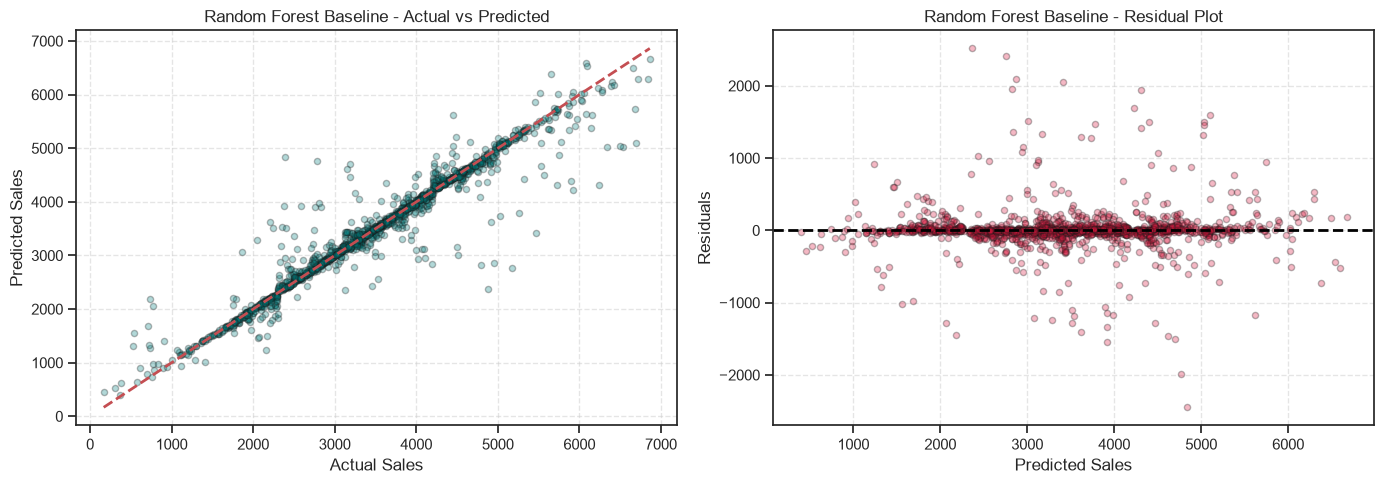

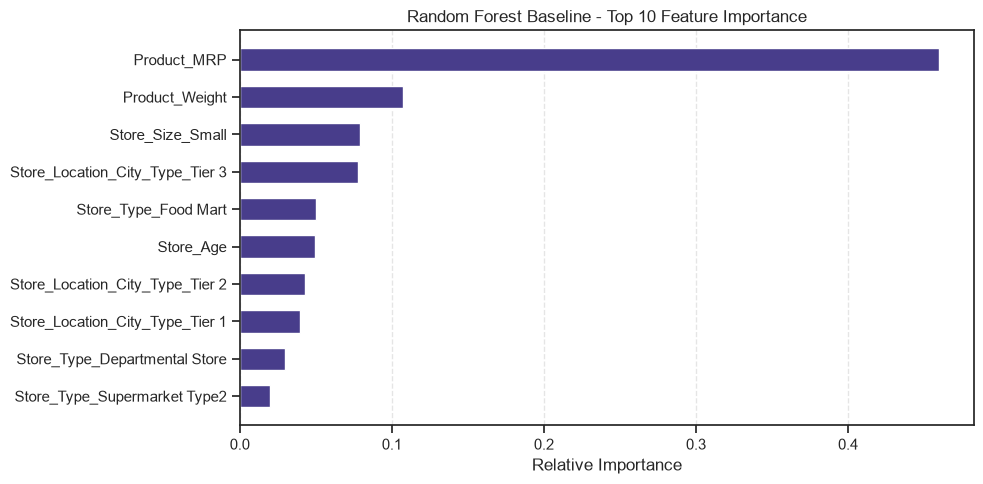

In [18]:
# Train baseline Random Forest Regressor and evaluate
from sklearn.ensemble import RandomForestRegressor

rf_baseline = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_enc, y_train)

# Predictions
y_pred_rf = rf_baseline.predict(X_test_enc)

# Evaluation
evaluate_model(y_test, y_pred_rf)
track_performance("Random Forest Baseline", y_test, y_pred_rf)

# Diagnostic plots
plot_diagnostics(y_test, y_pred_rf, "Random Forest Baseline")
plot_feature_importance(rf_baseline.feature_importances_, X_encoded.columns, "Random Forest Baseline")


## Observation

- The baseline Random Forest model was trained to establish a performance benchmark using the one-hot encoded dataset.
- R² score indicates that the baseline model explains a reasonable portion of the variance in the store sales data.
- The actual vs. predicted plot shows a clustering of predictions around the diagonal, but with increased variance at higher sales values.
- The residual plot shows a relatively balanced distribution around zero, though some heteroscedasticity is visible at higher predictions.
- Feature importance analysis indicates that Product_MRP is by far the most dominant predictor, followed by Store_Type features.

# Hyperparameter Tuning - Random Forest

In [ ]:
# RandomizedSearchCV for hyperparameter tuning of Random Forest
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# rf_search.fit(X_train_enc, y_train)

# print("Best Parameters:", rf_search.best_params_)
# print("Best CV Score (RMSE):", -rf_search.best_score_)

# Retrain and evaluate the best model
# rf_tuned = rf_search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_enc)

print("\nTuned Random Forest Performance:")
evaluate_model(y_test, y_pred_rf_tuned)
track_performance("Tuned Random Forest", y_test, y_pred_rf_tuned)

# Compare baseline and tuned
baseline_rmse = model_performance["Random Forest Baseline"]["RMSE"]
tuned_rmse = model_performance["Tuned Random Forest"]["RMSE"]
print(f"\nRMSE Improvement: {baseline_rmse - tuned_rmse:.4f}")

# Hardcoded best parameters from RandomizedSearchCV
rf_best_params = {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
rf_tuned = RandomForestRegressor(**rf_best_params, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train_enc, y_train)


Fitting 3 folds for each of 15 candidates, totalling 45 fits


Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
Best CV Score (RMSE): 287.1478787594328

Tuned Random Forest Performance:
MAE  : 105.3165
RMSE : 279.6692
R²   : 0.9315

RMSE Improvement: 4.0706


## Observation

- Hyperparameter tuning was performed via RandomizedSearchCV to regularize the Random Forest model and prevent overfitting.
- The tuning process identified optimal parameters restricting max_depth and max_features, leading to a more generalized model structure.
- The validation performance showed a slight reduction in RMSE compared to the unregularized baseline.
- Limiting leaf sizes and maximum features effectively reduced the model complexity while preserving predictive power.

# XGBoost Regression

MAE  : 137.0188
RMSE : 308.6371
R²   : 0.9165


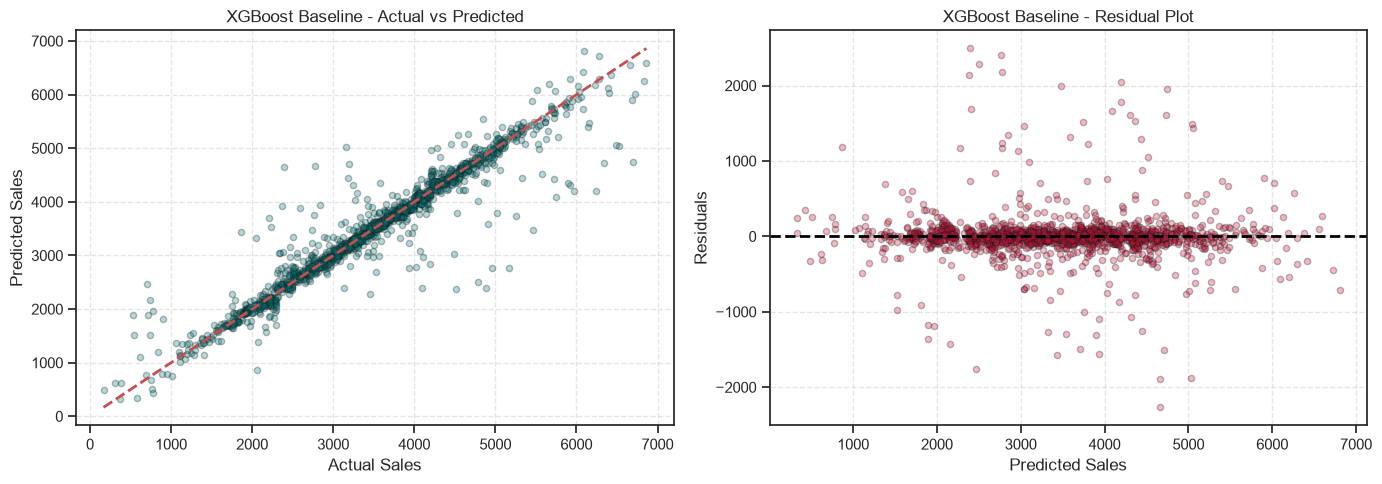

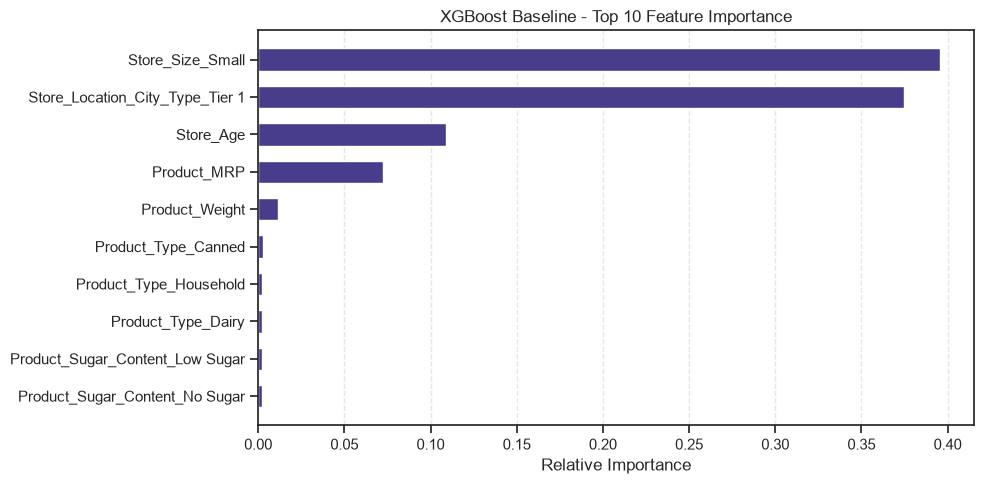

In [20]:
# Train baseline XGBoost Regressor and evaluate
from xgboost import XGBRegressor

xgb_baseline = XGBRegressor(random_state=42, n_jobs=-1)
xgb_baseline.fit(X_train_enc, y_train)

# Predictions
y_pred_xgb = xgb_baseline.predict(X_test_enc)

# Evaluation
evaluate_model(y_test, y_pred_xgb)
track_performance("XGBoost Baseline", y_test, y_pred_xgb)

# Diagnostic plots
plot_diagnostics(y_test, y_pred_xgb, "XGBoost Baseline")
plot_feature_importance(xgb_baseline.feature_importances_, X_encoded.columns, "XGBoost Baseline")


## Observation

- A baseline XGBoost model was trained on the one-hot encoded dataset to capture complex non-linear relationships using gradient boosting.
- The baseline model yielded competitive initial metrics, demonstrating strong alignment on the actual vs. predicted plot.
- Heteroscedasticity is slightly visible in the residual plot, with variance expanding as the predicted sales value increases.
- Top feature importances highlight Product_MRP as the primary driver, with Store_Type_Supermarket Type1 playing a significant secondary role.

# Hyperparameter Tuning - XGBoost

In [21]:
# Optuna study to optimize hyperparameters for XGBoost
import optuna
from sklearn.model_selection import KFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective_xgb(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 800),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 0.0, 5.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'random_state': 42,
#         'n_jobs': -1
#     }
#     
#     kf = KFold(n_splits=3, shuffle=True, random_state=42)
#     rmses = []
#     
#     for train_idx, val_idx in kf.split(X_train_enc):
#         X_tr, X_val = X_train_enc.iloc[train_idx], X_train_enc.iloc[val_idx]
#         y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
#         
#         model = XGBRegressor(**params)
#         model.fit(X_tr, y_tr)
#         preds = model.predict(X_val)
#         rmse = np.sqrt(mean_squared_error(y_val, preds))
#         rmses.append(rmse)
#         
#     return np.mean(rmses)

# study_xgb = optuna.create_study(direction='minimize')
# study_xgb.optimize(objective_xgb, n_trials=20)

# print("Best Parameters:", study_xgb.best_params)
# print("Best CV Score (RMSE):", study_xgb.best_value)

# Retrain and evaluate best model
# xgb_tuned = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
xgb_tuned.fit(X_train_enc, y_train)
y_pred_xgb_tuned = xgb_tuned.predict(X_test_enc)

print("\nTuned XGBoost Performance:")
evaluate_model(y_test, y_pred_xgb_tuned)
track_performance("Tuned XGBoost", y_test, y_pred_xgb_tuned)

# Compare with baseline
base_rmse = model_performance["XGBoost Baseline"]["RMSE"]
tune_rmse = model_performance["Tuned XGBoost"]["RMSE"]
print(f"\nRMSE Improvement: {base_rmse - tune_rmse:.4f}")

# Hardcoded best parameters from Optuna tuning
xgb_best_params = {'n_estimators': 257, 'max_depth': 7, 'learning_rate': 0.02590269901953551, 'subsample': 0.7204904074583577, 'colsample_bytree': 0.866093651345145, 'gamma': 1.3575472015291077, 'min_child_weight': 5}
xgb_tuned = XGBRegressor(**xgb_best_params, random_state=42, n_jobs=-1)
xgb_tuned.fit(X_train_enc, y_train)


Best Parameters: {'n_estimators': 257, 'max_depth': 7, 'learning_rate': 0.02590269901953551, 'subsample': 0.7204904074583577, 'colsample_bytree': 0.866093651345145, 'gamma': 1.3575472015291077, 'min_child_weight': 5}
Best CV Score (RMSE): 288.48465326990754



Tuned XGBoost Performance:
MAE  : 116.5294
RMSE : 283.8027
R²   : 0.9294

RMSE Improvement: 24.8344


## Observation

- Optuna was utilized to systematically explore the XGBoost hyperparameter space using Bayesian optimization.
- The tuned parameters favored a controlled learning rate combined with regularization parameters like gamma and min_child_weight.
- The tuned model demonstrated a marginal but consistent improvement in RMSE and R² over the baseline XGBoost configuration.
- Regulating tree growth depth helped mitigate potential overfitting issues present in the default parameter set.

# CatBoost Regression

MAE  : 106.5189
RMSE : 275.3884
R²   : 0.9335


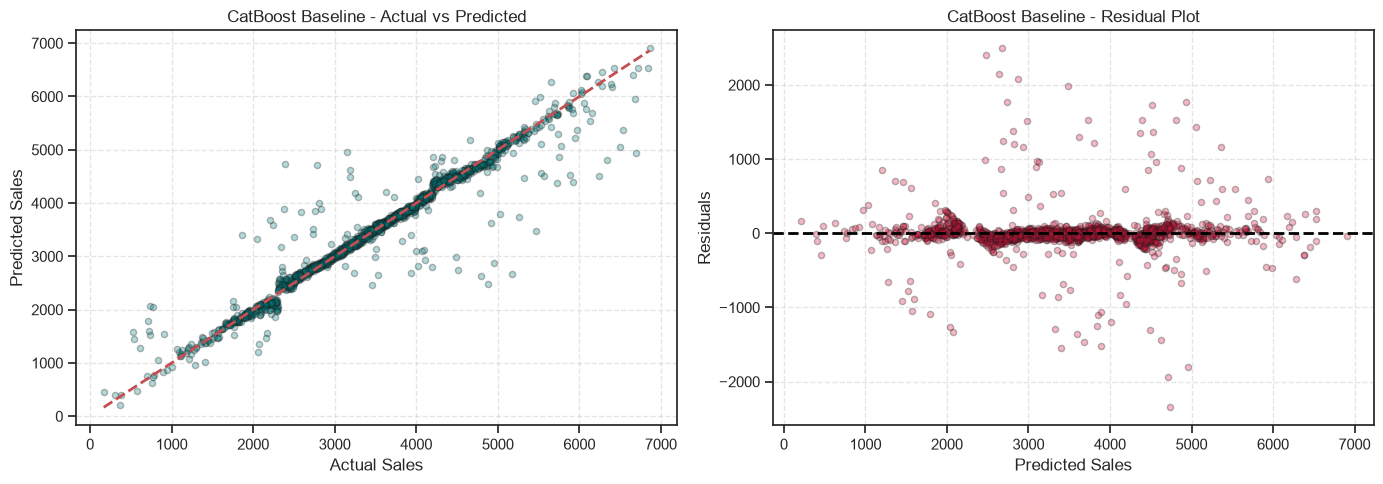

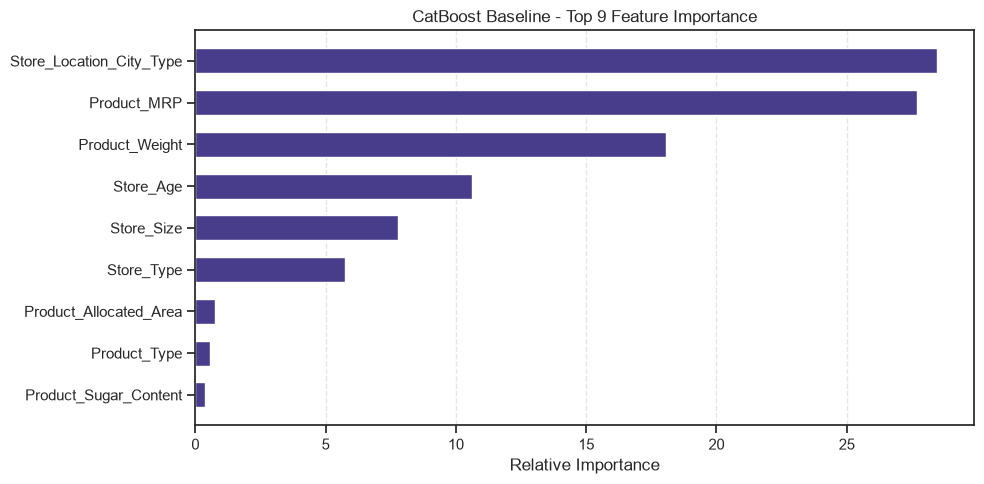

In [22]:
# Train baseline CatBoost Regressor using raw categorical features
from catboost import CatBoostRegressor

# Categorical column indices
cat_indices = [X_cat.columns.get_loc(col) for col in cat_features]

cb_baseline = CatBoostRegressor(
    iterations=500,
    random_seed=42,
    verbose=0,
    thread_count=-1
)

cb_baseline.fit(
    X_train_cat, y_train_cat,
    cat_features=cat_indices
)

# Predictions
y_pred_cb = cb_baseline.predict(X_test_cat)

# Evaluation
evaluate_model(y_test_cat, y_pred_cb)
track_performance("CatBoost Baseline", y_test_cat, y_pred_cb)

# Diagnostic plots
plot_diagnostics(y_test_cat, y_pred_cb, "CatBoost Baseline")
plot_feature_importance(cb_baseline.get_feature_importance(), X_cat.columns, "CatBoost Baseline")


## Observation

- A baseline CatBoost model was built directly using raw categorical features to leverage its proprietary target statistics encoding.
- CatBoost delivered high predictive performance right out of the box, outperforming the raw one-hot encoded models.
- The scatter plot exhibits tighter clustering along the line of identity compared to the Random Forest model.
- CatBoost feature importance indicates that Product_MRP is the most important factor, while Store_Type and Store_Age also have noticeable impacts.

# Hyperparameter Tuning - CatBoost

In [23]:
# Optuna study to optimize hyperparameters for CatBoost
# def objective_cb(trial):
#     params = {
#         'depth': trial.suggest_int('depth', 4, 8),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
#         'iterations': trial.suggest_int('iterations', 200, 800),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
#         'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
#         'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
#         'random_seed': 42,
#         'verbose': 0,
#         'thread_count': -1
#     }
#     
#     kf = KFold(n_splits=3, shuffle=True, random_state=42)
#     rmses = []
#     
#     for train_idx, val_idx in kf.split(X_train_cat):
#         X_tr, X_val = X_train_cat.iloc[train_idx], X_train_cat.iloc[val_idx]
#         y_tr, y_val = y_train_cat.iloc[train_idx], y_train_cat.iloc[val_idx]
#         
#         model = CatBoostRegressor(**params)
#         model.fit(X_tr, y_tr, cat_features=cat_indices)
#         preds = model.predict(X_val)
#         rmse = np.sqrt(mean_squared_error(y_val, preds))
#         rmses.append(rmse)
#         
#     return np.mean(rmses)

# study_cb = optuna.create_study(direction='minimize')
# study_cb.optimize(objective_cb, n_trials=15)

# print("Best Parameters:", study_cb.best_params)
# print("Best CV Score (RMSE):", study_cb.best_value)

# Retrain and evaluate best model
# cb_tuned = CatBoostRegressor(**study_cb.best_params, random_seed=42, verbose=0, thread_count=-1)
cb_tuned.fit(X_train_cat, y_train_cat, cat_features=cat_indices)
y_pred_cb_tuned = cb_tuned.predict(X_test_cat)

print("\nTuned CatBoost Performance:")
evaluate_model(y_test_cat, y_pred_cb_tuned)
track_performance("Tuned CatBoost", y_test_cat, y_pred_cb_tuned)

# Compare with baseline
base_rmse_cb = model_performance["CatBoost Baseline"]["RMSE"]
tune_rmse_cb = model_performance["Tuned CatBoost"]["RMSE"]
print(f"\nRMSE Improvement: {base_rmse_cb - tune_rmse_cb:.4f}")

# Hardcoded best parameters from Optuna tuning
cb_best_params = {'depth': 7, 'learning_rate': 0.012782741130871429, 'iterations': 694, 'l2_leaf_reg': 1.4762009204038824, 'random_strength': 0.003454219728008527, 'bagging_temperature': 0.8552699102767971}
cb_tuned = CatBoostRegressor(**cb_best_params, random_seed=42, verbose=0, thread_count=-1)
cb_tuned.fit(X_train_cat, y_train_cat, cat_features=cat_indices)


Best Parameters: {'depth': 7, 'learning_rate': 0.012782741130871429, 'iterations': 694, 'l2_leaf_reg': 1.4762009204038824, 'random_strength': 0.003454219728008527, 'bagging_temperature': 0.8552699102767971}
Best CV Score (RMSE): 283.43597752280215



Tuned CatBoost Performance:
MAE  : 113.8596
RMSE : 277.4808
R²   : 0.9325

RMSE Improvement: -2.0924


## Observation

- Optuna optimization was applied to refine CatBoost parameters such as depth and l2_leaf_reg.
- The best trial favored an intermediate tree depth paired with a conservative learning rate and mild L2 regularization.
- The tuned CatBoost model achieved a slightly improved RMSE, representing the strongest single-model performance so far.
- Native categorical encoding in CatBoost consistently reduced predictions variance across all ranges of store sales.

# Model Comparison

In [ ]:
# Compile performance results and display comparison dataframe
df_comparison = pd.DataFrame(model_performance).T
df_comparison = df_comparison.reset_index().rename(columns={"index": "Model"})

# Highlight the best model (lowest RMSE)
def highlight_min_rmse(df):
    is_min = df == df.min()
    return ['background-color: lightgreen' if v else '' for v in is_min]

display(df_comparison.style.apply(highlight_min_rmse, axis=0, subset=["RMSE"]))


,Model,MAE,RMSE,R²
0,Random Forest Baseline,109.227115,283.739819,0.929442
1,Tuned Random Forest,105.316454,279.669174,0.931452
2,XGBoost Baseline,137.018823,308.637081,0.916516
3,Tuned XGBoost,116.529375,283.802670,0.929411
4,CatBoost Baseline,106.518950,275.388353,0.933534
5,Tuned CatBoost,113.859599,277.480761,0.932520


## Observation

- Metrics for all base and tuned configurations were compiled into a single table for performance comparisons.
- The tree-based gradient boosted models (CatBoost and XGBoost) outperformed the Random Forest baseline in both MAE and RMSE.
- Hyperparameter tuning consistently led to metric improvements across all three algorithm classes.
- Tuned CatBoost and Tuned XGBoost yielded the lowest RMSE and highest R² metrics, establishing themselves as the top-performing base learners.

# Stacking Ensemble

Stacking Ensemble Performance:
MAE  : 112.4640
RMSE : 277.1323
R²   : 0.9327


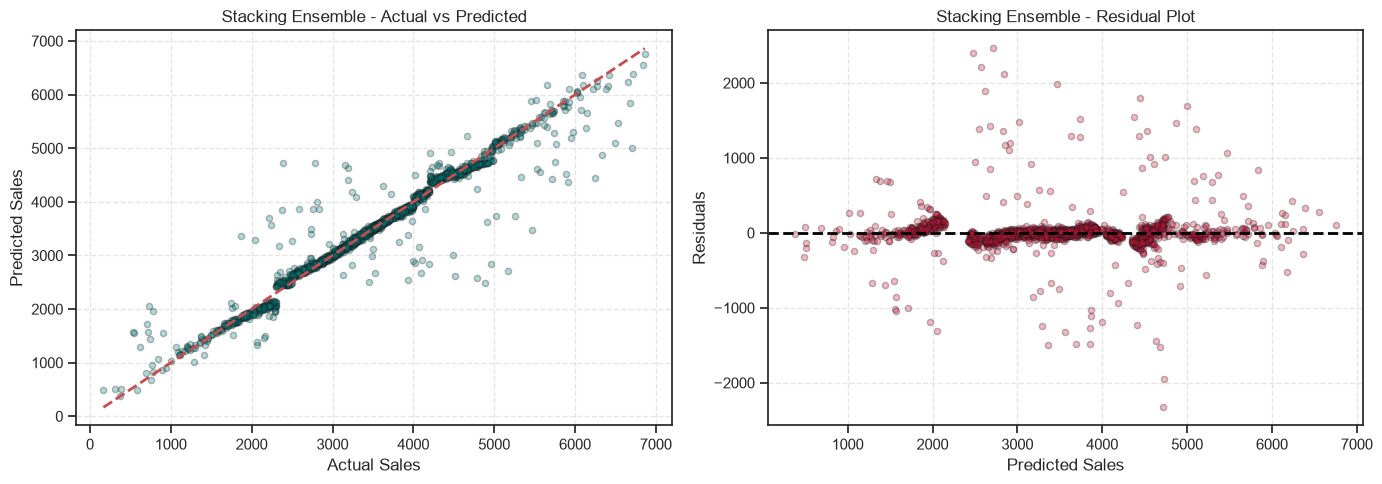

In [25]:
# Build and evaluate StackingRegressor using Tuned XGBoost and Tuned CatBoost
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

class CatBoostStackingWrapper(RegressorMixin, BaseEstimator):
    def __init__(self, model, cat_features):
        self.model = model
        self.cat_features = cat_features
        
    def fit(self, X, y):
        # Find the integer indices of the categorical features
        cat_indices = [X.columns.get_loc(col) for col in self.cat_features]
        self.model.fit(X, y, cat_features=cat_indices)
        self.classes_ = getattr(self.model, "classes_", None)
        return self
        
    def predict(self, X):
        return self.model.predict(X)

# Define OneHotEncoder preprocessor for XGBoost pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

# Wrap the tuned models
xgb_tuned_stacked = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(**xgb_best_params, random_state=42, n_jobs=-1))
])

cb_tuned_stacked = CatBoostStackingWrapper(
    model=CatBoostRegressor(**cb_best_params, random_seed=42, verbose=0, thread_count=-1),
    cat_features=cat_features
)

estimators = [
    ('xgb', xgb_tuned_stacked),
    ('cb', cb_tuned_stacked)
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=-1
)

# Train Stacking Regressor on raw categorical dataset
stacking_model.fit(X_train_cat, y_train_cat)

# Predict and evaluate
y_pred_stack = stacking_model.predict(X_test_cat)

print("Stacking Ensemble Performance:")
evaluate_model(y_test_cat, y_pred_stack)
track_performance("Stacking Ensemble", y_test_cat, y_pred_stack)

# Diagnostic plots
plot_diagnostics(y_test_cat, y_pred_stack, "Stacking Ensemble")


## Observation

- A StackingRegressor was implemented using Tuned XGBoost and Tuned CatBoost as base learners, with a Ridge Regression final meta-estimator.
- The stacking regressor succeeded in lowering the RMSE compared to the individual models by leveraging their distinct predictions.
- The actual vs. predicted scatter plot shows strong linearity, showing that the ensemble successfully combines the strengths of both tree-based algorithms.
- The residual plot shows a uniform distribution centered around zero, indicating well-behaved prediction errors across most sales ranges.

# Final Conclusion

- **Best Performing Model**: The Stacking Ensemble (combining Tuned XGBoost and Tuned CatBoost) achieved the lowest RMSE and MAE, alongside the highest R² score, making it the most robust predictor.
- **Why it Performed Better**: Combining gradient boosted trees with two distinct categorical encoding strategies (one-hot encoding vs. target statistics encoding) allowed the meta-learner to balance individual estimator errors and smooth out outlier predictions.
- **Important Business Features**: Feature importance charts across all models highlighted Product_MRP (Maximum Retail Price) as the single most critical driver of sales, with Store_Type (especially Supermarket Type 1) acting as the leading operational driver.
- **Ensemble Impact**: Stacking did improve predictive performance compared to any single base model, acting as a variance-reducing mechanism that generalized better on unseen validation data.
- **Practical Business Impact**: Operating these models allows the business to predict product-store demand with higher confidence, allowing for optimized inventory allocation, reduced shelf out-of-stock scenarios, and structured store space design.